# Positive vector-valued transport with coupled mobilities

This notebook generates the arrow-only figure used in the section on positive vector-valued measures.  The base is one-dimensional, while each point carries a positive vector

$$\nu_t(x)=(u_t^1(x),u_t^2(x))\in\mathbb R_+^2.$$

The conservative continuity equation remains componentwise,

$$\partial_t u_t^k+\partial_x V_t^k=0,$$

but the kinetic cost can couple channels through the mobility

$$
\mathsf M_\kappa(u)=\operatorname{diag}(u)+\kappa (u_1+u_2) q q^\top,
\qquad q=2^{-1/2}(1,1).
$$

Both endpoint measures are mixtures of two localized modes.  Inside each mode, the two channel densities are Gaussian bumps with the same center and width, but different amplitudes.  This makes the local fiber composition readable: each spatial mode carries a positive vector of channel weights.

The left panel is the exact diagonal case $\kappa=0$, where each channel follows its own one-dimensional $W_2$ geodesic.  The right panel is a lightweight large-$\kappa$ common-mode display: channel particles keep their endpoints and masses, but their mid-time trajectories are bent toward the transport of the total density $u^1+u^2$, illustrating the preference for common-channel motion when $\kappa$ is large.


In [1]:
from __future__ import annotations

from pathlib import Path
import contextlib
import io
import sys
from typing import Iterable

from matplotlib.collections import LineCollection
from matplotlib.colors import to_rgb
import matplotlib.pyplot as plt
import numpy as np

HERE = Path.cwd().resolve()
ROOT = HERE.parent if HERE.name == "notebooks-figures" else HERE
if not (ROOT / "latex").exists():
    ROOT = Path("/Users/gpeyre/Dropbox/github/ot4ml")

sys.path.insert(0, str(ROOT / "notebooks-figures"))
from figure_style import BLUE, LIGHT_GRAY, RED, box_axes, interp_color, save_pdf, setup_matplotlib

setup_matplotlib()

FIGURE_NAME = "vector-valued-measure-geodesics"
OUT_DIR = ROOT / "latex" / "figures" / FIGURE_NAME
OUT_DIR.mkdir(parents=True, exist_ok=True)
THUMB_DIR = ROOT / "notebooks-figures" / "thumbnails"
THUMB_DIR.mkdir(parents=True, exist_ok=True)

Packet = tuple[float, float, float]  # mass, mean, standard deviation


## Quantile particles and coupled paths

Each channel is represented by deterministic quantile particles.  For $\kappa=0$, a particle moves on the straight 1D Wasserstein segment between its source and target quantiles.  For the large-$\kappa$ display, particles are bent toward the transport of the total density during the middle of the interpolation, and the mid-time channel contrast is damped toward the common direction $q=2^{-1/2}(1,1)$.  The factors vanish at $t=0$ and $t=1$, so endpoints and channel masses are unchanged.


In [2]:
def gaussian_density(x: np.ndarray, mean: float, sigma: float) -> np.ndarray:
    return np.exp(-0.5 * ((x - mean) / sigma) ** 2) / (np.sqrt(2 * np.pi) * sigma)


def total_packet_mass(packets: Iterable[Packet]) -> float:
    return float(sum(w for w, _, _ in packets))


def mixture_density(x: np.ndarray, packets: list[Packet]) -> np.ndarray:
    rho = np.zeros_like(x, dtype=float)
    for weight, mean, sigma in packets:
        rho += weight * gaussian_density(x, mean, sigma)
    dx = x[1] - x[0]
    mass = total_packet_mass(packets)
    rho *= mass / max(float(rho.sum() * dx), 1e-15)
    return rho


def smooth_density(rho: np.ndarray, dx: float, sigma: float) -> np.ndarray:
    if sigma <= 0:
        return rho.copy()
    radius = max(1, int(np.ceil(4 * sigma / dx)))
    z = np.arange(-radius, radius + 1) * dx
    kernel = np.exp(-0.5 * (z / sigma) ** 2)
    kernel /= kernel.sum()
    return np.convolve(rho, kernel, mode="same")


def quantile_samples(x: np.ndarray, rho: np.ndarray, n_quantiles: int) -> tuple[np.ndarray, np.ndarray]:
    dx = x[1] - x[0]
    mass = float(rho.sum() * dx)
    cdf = np.cumsum(rho) * dx
    cdf[-1] = mass
    cdf = np.r_[0.0, cdf]
    x_ext = np.r_[x[0], x]
    q = (np.arange(n_quantiles) + 0.5) * mass / n_quantiles
    return q, np.interp(q, cdf, x_ext)


def inverse_cdf(x: np.ndarray, rho: np.ndarray, q: np.ndarray) -> np.ndarray:
    dx = x[1] - x[0]
    mass = float(rho.sum() * dx)
    cdf = np.cumsum(rho) * dx
    cdf[-1] = mass
    return np.interp(q, np.r_[0.0, cdf], np.r_[x[0], x])


def cdf_values(x: np.ndarray, rho: np.ndarray, positions: np.ndarray) -> np.ndarray:
    dx = x[1] - x[0]
    cdf = np.cumsum(rho) * dx
    cdf[-1] = float(rho.sum() * dx)
    return np.interp(positions, x, cdf, left=0.0, right=cdf[-1])


def densities_from_paths(
    x: np.ndarray,
    paths: np.ndarray,
    mass: float,
    *,
    smooth_sigma: float = 0.024,
) -> np.ndarray:
    dx = x[1] - x[0]
    edges = np.r_[x - 0.5 * dx, x[-1] + 0.5 * dx]
    weight = np.full(paths.shape[1], mass / paths.shape[1])
    series = []
    for xt in paths:
        hist, _ = np.histogram(xt, bins=edges, weights=weight)
        rho = smooth_density(hist / dx, dx, smooth_sigma)
        rho *= mass / max(float(rho.sum() * dx), 1e-15)
        series.append(rho)
    return np.asarray(series)


def damp_channel_contrast(series: np.ndarray, times: np.ndarray, *, eta: float) -> np.ndarray:
    """Move the fiber values toward the common channel direction at mid-time."""
    total = series[0] + series[1]
    diff = series[0] - series[1]
    out = np.empty_like(series)
    for j, t in enumerate(times):
        shrink = 1.0 - eta * np.sin(np.pi * t)
        out[0, j] = 0.5 * (total[j] + shrink * diff[j])
        out[1, j] = 0.5 * (total[j] - shrink * diff[j])
    if out.min() < -1e-12:
        raise RuntimeError("The coupled display lost positivity.")
    return np.maximum(out, 0.0)


def build_channel_paths(
    x: np.ndarray,
    channels0: list[list[Packet]],
    channels1: list[list[Packet]],
    times: np.ndarray,
    *,
    gamma: float,
    n_quantiles: int = 7000,
) -> np.ndarray:
    rho0 = [mixture_density(x, packets) for packets in channels0]
    rho1 = [mixture_density(x, packets) for packets in channels1]
    total0 = rho0[0] + rho0[1]
    total1 = rho1[0] + rho1[1]

    series = []
    for k in range(2):
        mass = total_packet_mass(channels0[k])
        if abs(mass - total_packet_mass(channels1[k])) > 1e-12:
            raise ValueError("Conservative vector transport requires matching channel masses.")
        _, x0 = quantile_samples(x, rho0[k], n_quantiles)
        _, x1 = quantile_samples(x, rho1[k], n_quantiles)
        q_total = cdf_values(x, total0, x0)
        y_common = inverse_cdf(x, total1, q_total)
        paths = []
        for t in times:
            independent = (1 - t) * x0 + t * x1
            common = (1 - t) * x0 + t * y_common
            bend = gamma * np.sin(np.pi * t)
            paths.append((1 - bend) * independent + bend * common)
        series.append(densities_from_paths(x, np.asarray(paths), mass))
    return np.asarray(series)


## Endpoint data

Both endpoints are mixtures of two localized spatial modes.  The channel profiles share the same two mode centers at each endpoint; only the amplitudes of the two channels differ from one mode to the other.  Each channel has unit mass, so the conservative vector transport constraint is satisfied.


In [3]:
x = np.linspace(-2.55, 2.55, 820)
times_glyph = np.linspace(0, 1, 8)

source_centers = (-1.48, 0.78)
target_centers = (-0.72, 1.48)
source_sigmas = (0.16, 0.18)
target_sigmas = (0.17, 0.16)

# At each spatial mode the two channels have the same Gaussian center.
# The amplitudes are chosen so that the independent channels exchange mass
# between the two modes, whereas the total density remains nearly mode-wise.
channels0: list[list[Packet]] = [
    [(0.76, source_centers[0], source_sigmas[0]), (0.24, source_centers[1], source_sigmas[1])],
    [(0.22, source_centers[0], source_sigmas[0]), (0.78, source_centers[1], source_sigmas[1])],
]
channels1: list[list[Packet]] = [
    [(0.28, target_centers[0], target_sigmas[0]), (0.72, target_centers[1], target_sigmas[1])],
    [(0.76, target_centers[0], target_sigmas[0]), (0.24, target_centers[1], target_sigmas[1])],
]

series_independent = build_channel_paths(x, channels0, channels1, times_glyph, gamma=0.0)
series_coupled = build_channel_paths(x, channels0, channels1, times_glyph, gamma=0.98)
series_coupled = damp_channel_contrast(series_coupled, times_glyph, eta=0.76)

for series in (series_independent, series_coupled):
    dx = x[1] - x[0]
    for k in range(2):
        mass = total_packet_mass(channels0[k])
        np.testing.assert_allclose(series[k].sum(axis=1) * dx, mass, rtol=6e-4, atol=6e-4)

print("channel masses:", [total_packet_mass(p) for p in channels0])
print("source mode centers:", source_centers)
print("target mode centers:", target_centers)
print("max endpoint discrepancy:", float(np.max(np.abs(series_independent[:, [0, -1]] - series_coupled[:, [0, -1]]))))


channel masses: [1.0, 1.0]
source mode centers: (-1.48, 0.78)
target mode centers: (-0.72, 1.48)
max endpoint discrepancy: 2.220446049250313e-16


## Arrow glyph rendering

At each sampled point $(x,t)$, the arrow is the positive fiber vector $(u_t^1(x),u_t^2(x))$.  It is not the spatial velocity; it records the local channel composition of the transported vector-valued density.


Only eight time levels are displayed, which leaves enough vertical room for larger glyphs and makes the channel composition readable in print.


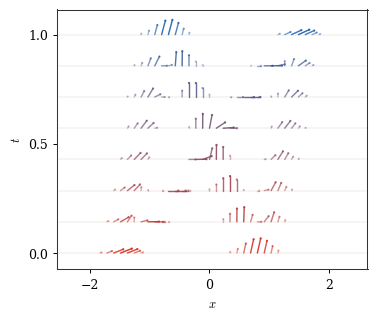

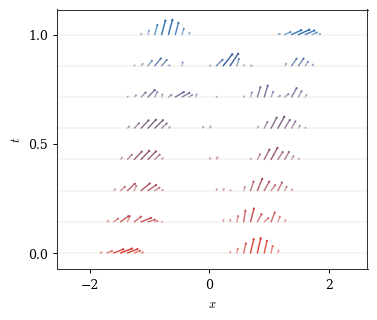

In [4]:
xq = np.linspace(-2.18, 2.18, 39)


def sampled_values(series: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    u = np.asarray([np.interp(xq, x, row) for row in series[0]])
    v = np.asarray([np.interp(xq, x, row) for row in series[1]])
    return u, v


U0, V0 = sampled_values(series_independent)
U1, V1 = sampled_values(series_coupled)
U_scale = max(float(np.quantile(np.r_[U0.ravel(), U1.ravel()], 0.985)), 1e-12)
V_scale = max(float(np.quantile(np.r_[V0.ravel(), V1.ravel()], 0.985)), 1e-12)
mag_all = np.sqrt((np.r_[U0.ravel(), U1.ravel()] / U_scale) ** 2 + (np.r_[V0.ravel(), V1.ravel()] / V_scale) ** 2)
mag_scale = max(float(np.quantile(mag_all, 0.985)), 1e-12)


def draw_positive_vector_glyphs(ax: plt.Axes, series: np.ndarray) -> None:
    U_values, V_values = sampled_values(series)
    segments = []
    colors = []
    tip_x = []
    tip_y = []
    tip_colors = []
    for j, t in enumerate(times_glyph):
        base_color = np.array(to_rgb(interp_color(float(t), RED, BLUE)))
        ax.axhline(t, color=LIGHT_GRAY, lw=0.30, zorder=0)
        u = U_values[j] / U_scale
        v = V_values[j] / V_scale
        mag = np.sqrt(u**2 + v**2)
        rel = np.tanh(mag / mag_scale) / np.tanh(max(float(mag_all.max() / mag_scale), 1e-12))
        dx_glyph = 0.205 * rel * np.divide(u, mag, out=np.zeros_like(u), where=mag > 1e-14)
        dy_glyph = 0.078 * rel * np.divide(v, mag, out=np.zeros_like(v), where=mag > 1e-14)
        for xi, dxi, dyi, ri in zip(xq, dx_glyph, dy_glyph, rel):
            if ri < 0.035:
                continue
            segments.append([(xi, t), (xi + dxi, t + dyi)])
            alpha = 0.25 + 0.75 * min(float(ri), 1.0)
            color = (*base_color, alpha)
            colors.append(color)
            tip_x.append(xi + dxi)
            tip_y.append(t + dyi)
            tip_colors.append(color)
    ax.add_collection(LineCollection(segments, colors=colors, linewidths=1.02, capstyle="round", zorder=2))
    ax.scatter(tip_x, tip_y, s=2.65, marker="o", color=tip_colors, linewidth=0, zorder=3)
    ax.set_xlim(x.min(), x.max() + 0.10)
    ax.set_ylim(-0.075, 1.115)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$t$")
    ax.set_yticks([0, 0.5, 1])
    ax.set_xticks([-2, 0, 2])
    box_axes(ax)


def save_arrow_panel(filename: str, series: np.ndarray) -> None:
    fig, ax = plt.subplots(figsize=(3.62, 3.05))
    draw_positive_vector_glyphs(ax, series)
    fig.tight_layout(pad=0.18)
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        save_pdf(fig, OUT_DIR / filename, pad_inches=0.025)
    plt.show()


save_arrow_panel("kappa-zero-arrows.pdf", series_independent)
save_arrow_panel("kappa-large-arrows.pdf", series_coupled)


## Thumbnail

The gallery thumbnail combines the two arrow displays.  Panel labels are supplied by LaTeX in the paper, so the exported PDFs contain no embedded titles.


Wrote /Users/gpeyre/Dropbox/github/ot4ml/latex/figures/vector-valued-measure-geodesics/kappa-zero-arrows.pdf
Wrote /Users/gpeyre/Dropbox/github/ot4ml/latex/figures/vector-valued-measure-geodesics/kappa-large-arrows.pdf
Wrote /Users/gpeyre/Dropbox/github/ot4ml/notebooks-figures/thumbnails/vector-valued-measure-geodesics.png


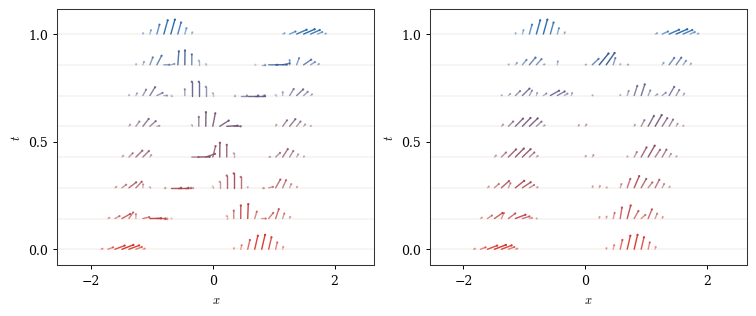

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(7.45, 3.05), constrained_layout=True)
draw_positive_vector_glyphs(axes[0], series_independent)
draw_positive_vector_glyphs(axes[1], series_coupled)
thumb_path = THUMB_DIR / f"{FIGURE_NAME}.png"
fig.savefig(thumb_path, dpi=180, bbox_inches="tight", pad_inches=0.04)
print(f"Wrote {OUT_DIR / 'kappa-zero-arrows.pdf'}")
print(f"Wrote {OUT_DIR / 'kappa-large-arrows.pdf'}")
print(f"Wrote {thumb_path}")
plt.show()
